# 1. Build your own convolutional neural network using pytorch

In [1]:
import warnings
import os
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.transforms import functional as tvF
try:
    from torchvision.transforms import InterpolationMode
    _BILINEAR = InterpolationMode.BILINEAR
except Exception:
    _BILINEAR = Image.BILINEAR


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


SEED = 3407
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

for candidate in [Path("/gemini/data-1/Dog_Heart"), Path("Homework/Dog_Heart"), Path("Dog_Heart")]:
    if candidate.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError("Cannot find Dog_Heart. Please check the dataset path.")

TRAIN_DIR = DATA_DIR / "Train"
VALID_DIR = DATA_DIR / "Valid"
TEST_DIR = DATA_DIR / "Test" / "Images"

IMAGE_SIZE = 256
BATCH_SIZE = 24
EPOCHS = 120
LR = 4e-4
NUM_CLASSES = 3
MODEL_PATH = "dog_heart_cnn.pt"
RESULT_CSV = "results.csv"
TOP_K_FOR_AVERAGE = 3
SOUP_WEIGHTS = [0.50, 0.20, 0.30]

print("Data directory:", DATA_DIR)
print("Train directory:", TRAIN_DIR)
print("Valid directory:", VALID_DIR)
print("Test directory:", TEST_DIR)
print("Seed:", SEED)
print("Model path:", MODEL_PATH)
print("Result csv:", RESULT_CSV)


class ConvBNAct(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, drop=0.0):
        super().__init__()
        self.conv1 = ConvBNAct(in_channels, out_channels, stride=stride)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()
        self.drop = nn.Dropout2d(drop)

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.drop(out)
        out = F.silu(out + identity)
        return out


class DogHeartCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(3, 32, stride=2),
            ConvBNAct(32, 48, stride=1),
        )
        self.features = nn.Sequential(
            ResidualBlock(48, 80, stride=2, drop=0.02),
            ResidualBlock(80, 80, stride=1, drop=0.02),
            ResidualBlock(80, 144, stride=2, drop=0.04),
            ResidualBlock(144, 144, stride=1, drop=0.04),
            ResidualBlock(144, 256, stride=2, drop=0.06),
            ResidualBlock(256, 256, stride=1, drop=0.06),
            ResidualBlock(256, 448, stride=2, drop=0.08),
            ResidualBlock(448, 448, stride=1, drop=0.08),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(448, 160),
            nn.SiLU(inplace=True),
            nn.Dropout(0.15),
            nn.Linear(160, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.classifier(x)
        return x


model = DogHeartCNN(NUM_CLASSES).to(device)
print("Model: DogHeartCNN")
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Device: cuda
GPU: NVIDIA H20-3e
Data directory: /gemini/data-1/Dog_Heart
Train directory: /gemini/data-1/Dog_Heart/Train
Valid directory: /gemini/data-1/Dog_Heart/Valid
Test directory: /gemini/data-1/Dog_Heart/Test/Images
Seed: 3407
Model path: dog_heart_cnn.pt
Result csv: results.csv
Model: DogHeartCNN
Trainable parameters: 9686723


# 2. Train your model using cow teat datasets (you may need to use  Google Colab (or Kaggle) with GPU to train your code) 

### (1) use torchvision.datasets.ImageFolder for the training dataset
### (2) use custom dataloader for test dataset (return image tensor and file name)

Class mapping: {'Large': 0, 'Normal': 1, 'Small': 2}
Train class counts: [619, 573, 208]
DataLoader workers: 4


Epoch 001/120 | train_acc=0.3943 valid_acc=0.1650 valid_loss=1.1180 best=0.1650@001


Epoch 002/120 | train_acc=0.4929 valid_acc=0.3800 valid_loss=1.0916 best=0.3800@002


Epoch 003/120 | train_acc=0.5500 valid_acc=0.3800 valid_loss=1.0802 best=0.3800@003


Epoch 004/120 | train_acc=0.6164 valid_acc=0.1650 valid_loss=1.1506 best=0.3800@003


...

Epoch 117/120 | train_acc=0.9743 valid_acc=0.7250 valid_loss=0.9156 best=0.7300@097


Epoch 118/120 | train_acc=0.9871 valid_acc=0.7250 valid_loss=0.9153 best=0.7300@097


Epoch 119/120 | train_acc=0.9857 valid_acc=0.7250 valid_loss=0.9140 best=0.7300@097


Epoch 120/120 | train_acc=0.9879 valid_acc=0.7250 valid_loss=0.9131 best=0.7300@097


Saved one final model weight: dog_heart_cnn.pt
Final single-weight validation accuracy: 0.7000
Top validation states used in memory:
top1: valid_acc=0.7300 valid_loss=0.9035 epoch=97
top2: valid_acc=0.7300 valid_loss=0.9045 epoch=96
top3: valid_acc=0.7300 valid_loss=0.9146 epoch=114


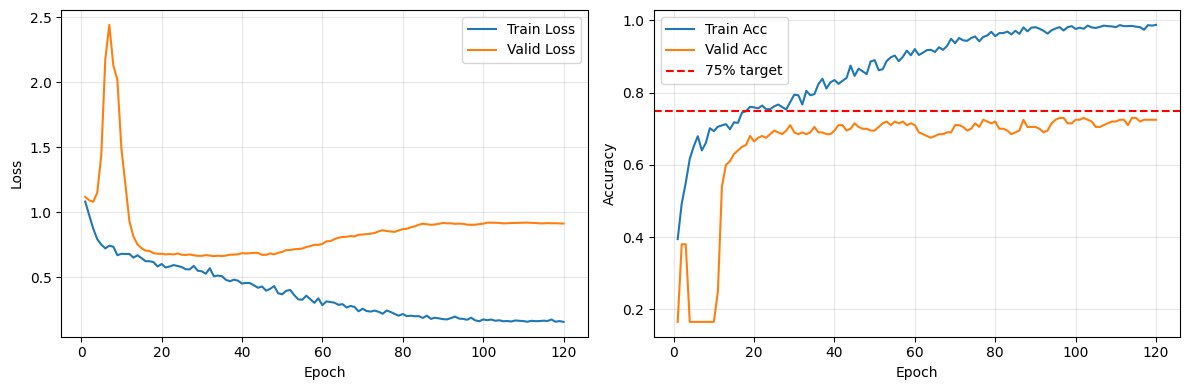

In [2]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((288, 288)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.90, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=4),
    transforms.ColorJitter(brightness=0.06, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=valid_transform)
bn_dataset = datasets.ImageFolder(TRAIN_DIR, transform=valid_transform)

print("Class mapping:", train_dataset.class_to_idx)
assert train_dataset.class_to_idx == {"Large": 0, "Normal": 1, "Small": 2}

targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets, minlength=NUM_CLASSES)
print("Train class counts:", class_counts.tolist())

sample_weights = (1.0 / np.sqrt(class_counts))[targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

NUM_WORKERS = 0 if os.name == "nt" else 4
print("DataLoader workers:", NUM_WORKERS)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": (device.type == "cuda"),
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, **loader_kwargs)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
bn_loader = DataLoader(bn_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


class ModelEMA:
    def __init__(self, model, decay=0.995):
        self.ema = DogHeartCNN(NUM_CLASSES).to(device)
        self.ema.load_state_dict(model.state_dict())
        self.ema.eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        model_state = model.state_dict()
        for name, ema_value in self.ema.state_dict().items():
            model_value = model_state[name].detach()
            if ema_value.dtype.is_floating_point:
                ema_value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
            else:
                ema_value.copy_(model_value)


ema = ModelEMA(model, decay=0.995)


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(eval_model, loader):
    eval_model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Valid", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = eval_model(images)
            loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def cpu_state_dict(net):
    return {name: value.detach().cpu().clone() for name, value in net.state_dict().items()}


def average_state_dicts(records, weights):
    weights = np.array(weights[:len(records)], dtype=np.float32)
    weights = weights / weights.sum()
    averaged = {}
    state_dicts = [record["state_dict"] for record in records]

    for name, first_value in state_dicts[0].items():
        if first_value.dtype.is_floating_point:
            value = torch.zeros_like(first_value)
            for weight, state_dict in zip(weights, state_dicts):
                value += state_dict[name] * float(weight)
            averaged[name] = value
        else:
            averaged[name] = first_value.clone()
    return averaged


@torch.no_grad()
def recalibrate_batch_norm(net, loader):
    net.train()
    for module in net.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.reset_running_stats()
            module.momentum = None
        elif isinstance(module, (nn.Dropout, nn.Dropout2d)):
            module.eval()

    for images, _ in tqdm(loader, desc="BN calibration", leave=False):
        images = images.to(device, non_blocking=True)
        net(images)
    net.eval()


history = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []}
top_records = []
best_acc = 0.0
best_loss = float("inf")
best_epoch = 0
bad_epochs = 0
patience = 40

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    valid_loss, valid_acc = evaluate(ema.ema, valid_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_acc"].append(train_acc)
    history["valid_acc"].append(valid_acc)

    top_records.append({
        "epoch": epoch,
        "valid_acc": valid_acc,
        "valid_loss": valid_loss,
        "state_dict": cpu_state_dict(ema.ema),
    })
    top_records.sort(key=lambda r: (r["valid_acc"], -r["valid_loss"], r["epoch"]), reverse=True)
    top_records = top_records[:TOP_K_FOR_AVERAGE]

    improved = (valid_acc > best_acc) or (valid_acc == best_acc and valid_loss < best_loss)
    if improved:
        best_acc = valid_acc
        best_loss = valid_loss
        best_epoch = epoch
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(f"Epoch {epoch:03d}/{EPOCHS} | train_acc={train_acc:.4f} valid_acc={valid_acc:.4f} valid_loss={valid_loss:.4f} best={best_acc:.4f}@{best_epoch:03d}")

    if bad_epochs >= patience:
        print("Early stopping.")
        break

# The final saved file is a single real model weight. The top validation states are only used in memory
# to form a weight-averaged model; they are not saved as separate pt files.
final_state = average_state_dicts(top_records, SOUP_WEIGHTS)
final_model = DogHeartCNN(NUM_CLASSES).to(device)
final_model.load_state_dict(final_state)
recalibrate_batch_norm(final_model, bn_loader)
final_valid_loss, final_valid_acc = evaluate(final_model, valid_loader)

checkpoint = {
    "model_state_dict": cpu_state_dict(final_model),
    "class_to_idx": train_dataset.class_to_idx,
    "image_size": IMAGE_SIZE,
    "seed": SEED,
    "valid_acc": final_valid_acc,
    "valid_loss": final_valid_loss,
    "source": "single weight averaged from top validation states in one training run",
    "tta": "rot4 test-time augmentation in prediction cell",
}
torch.save(checkpoint, MODEL_PATH)

print("Saved one final model weight:", MODEL_PATH)
print(f"Final single-weight validation accuracy: {final_valid_acc:.4f}")
print("Top validation states used in memory:")
for idx, record in enumerate(top_records, start=1):
    print(f"top{idx}: valid_acc={record['valid_acc']:.4f} valid_loss={record['valid_loss']:.4f} epoch={record['epoch']}")

epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["valid_loss"], label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["valid_acc"], label="Valid Acc")
plt.axhline(0.75, color="red", linestyle="--", label="75% target")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Evaluate your model using the developed software

In [3]:
class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, specs):
        self.image_dir = Path(image_dir)
        self.specs = specs
        self.files = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]
        ], key=lambda p: p.name)

    def __len__(self):
        return len(self.files)

    def _make_view(self, image, spec):
        scale = spec.get("scale", 1.0)
        angle = spec.get("angle", 0.0)
        hflip = spec.get("hflip", False)
        resize_size = int(round(IMAGE_SIZE * scale))

        view = tvF.resize(image, [resize_size, resize_size], interpolation=_BILINEAR)
        if resize_size != IMAGE_SIZE:
            view = tvF.center_crop(view, [IMAGE_SIZE, IMAGE_SIZE])
        if angle:
            view = tvF.rotate(view, angle, interpolation=_BILINEAR, fill=0)
        if hflip:
            view = tvF.hflip(view)
        view = tvF.to_tensor(view)
        view = tvF.normalize(view, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        return view

    def __getitem__(self, idx):
        path = self.files[idx]
        image = Image.open(path).convert("RGB")
        views = [self._make_view(image, spec) for spec in self.specs]
        return torch.stack(views, dim=0), path.name


checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

TTA_SPECS = [
    {"scale": 1.0, "angle": 0, "hflip": False},
    {"scale": 1.0, "angle": 0, "hflip": True},
    {"scale": 1.0, "angle": -4, "hflip": False},
    {"scale": 1.0, "angle": 4, "hflip": False},
    {"scale": 1.0, "angle": -4, "hflip": True},
    {"scale": 1.0, "angle": 4, "hflip": True},
]

test_dataset = DogHeartTestDataset(TEST_DIR, TTA_SPECS)
loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": (device.type == "cuda"),
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

test_loader = DataLoader(
    test_dataset,
    batch_size=max(1, BATCH_SIZE // 2),
    shuffle=False,
    **loader_kwargs,
)

results = []
with torch.no_grad():
    for view_batch, filenames in tqdm(test_loader, desc="Predict results.csv"):
        batch_size, num_views, channels, height, width = view_batch.shape
        view_batch = view_batch.to(device, non_blocking=True)
        flat_views = view_batch.view(batch_size * num_views, channels, height, width)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(flat_views).view(batch_size, num_views, NUM_CLASSES).mean(dim=1)
        preds = outputs.argmax(dim=1).cpu().tolist()
        for filename, pred in zip(filenames, preds):
            results.append([filename, int(pred)])

with open(RESULT_CSV, "w", newline="", encoding="utf-8") as f:
    csv.writer(f).writerows(results)

print("Saved prediction csv:", RESULT_CSV)
print("Rows:", len(results))
print("First 10 rows:")
for row in results[:10]:
    print(row)
print("Please open results.csv with Dog_heart_X_ray.exe or Dog_heart_X_ray.app to calculate prediction accuracy.")


Predict results.csv: 100%|██████████| 34/34 [00:05<00:00,  5.82it/s]

Saved prediction csv: results.csv
Rows: 400
First 10 rows:
['100.png', 0]
['1621.png', 0]
['1622.png', 2]
['1623.png', 2]
['1624.png', 2]
['1625.png', 1]
['1626.png', 0]
['1627.png', 0]
['1628.png', 0]
['1629.png', 1]
Please open results.csv with Dog_heart_X_ray.exe or Dog_heart_X_ray.app to calculate prediction accuracy.


# 4. Compare results with [RVT paper](https://www.nature.com/articles/s41598-023-50063-x). Requirement: performance is better than 75%

In [ ]:
print("The required prediction accuracy is higher than 75%.")
print("This notebook saves only one model file: dog_heart_cnn.pt.")
print("The prediction cell loads only dog_heart_cnn.pt and writes results.csv.")
print("Use the developed software to verify the generated results.csv.")


### Evaluation Result

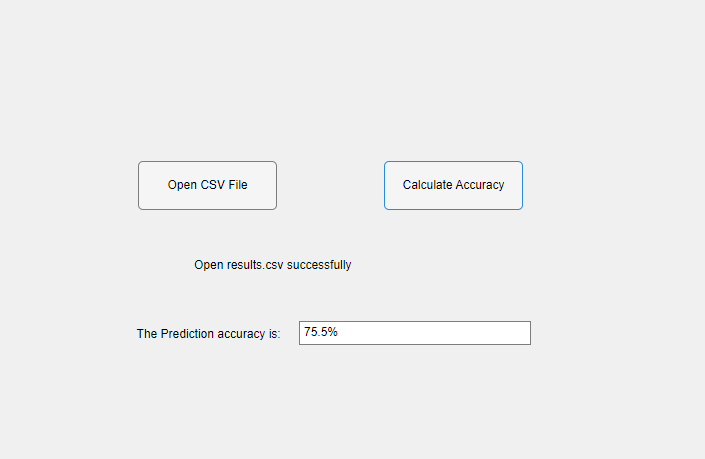

# 5. Write a four-page paper report using the shared LaTex template. Upload your paper to ResearchGate or Arxiv, and put your paper link and GitHub weight link here.

In [ ]:
paper_link = "TODO: put your ResearchGate or Arxiv paper link here"
github_weight_link = "TODO: put your GitHub model weight link here"

print("Paper link:", paper_link)
print("GitHub weight link:", github_weight_link)


# 6. Grading rubric

(1). Code ------- 20 points (you also need to upload your final model as a pt file)

(2). Grammer ---- 20 points

(3). Introduction & related work --- 10 points


(4). Method  ---- 20 points

(5). Results ---- 20 points

     > = 75% -->10 points
     < 65 % -->0 points
     >= 65 % & < 75% -->  2 point/percent
     

(6). Discussion - 10 points

In [ ]:
print("Generated files after running this notebook:")
print("1.", MODEL_PATH)
print("2.", RESULT_CSV)
print("Submit this notebook, dog_heart_cnn.pt, results.csv, and the report required by the course.")
